In [104]:
xl = pd.read_csv('OSMI_survey_2014.csv')
xl['state'].nunique()

45

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df= pd.read_csv('OSMI_survey_2014.csv')

# checking for abnormalities in the 'Age' column
df['Age'].max() # max age is 99999999999, clearly a false entry
df['Age'].min() # min age is -1726, cleary a false entry

# We shall create a dataset where only age values between 18 to 75 are considered (safe bracket for a tech worker)
# For all other ages, NaN will be entered
df['Age'] = np.where((df['Age'] < 18) | (df['Age'] > 75), np.nan, df['Age'])


In [106]:
df['Gender'].value_counts() # many different entries for gender

# removing all textual differences in 'Gender' resulting from upper/lowercase-dscrepancy or extra spaces
df['Gender'] = df['Gender'].str.lower().str.strip()

# making uniform arrays for male and female of the unique values found in the 'Gender' column
male_terms = ['male', 'm', 'man', 'cis male', 'cis man', 'mail', 'make'] 
female_terms = ['female', 'f', 'woman', 'cis female', 'cis woman', 'femake', 'femail'] 

# nested where syntax to check for female, then make, and then others
df['Gender'] = np.where(df['Gender'].isin(female_terms), "female", 
                       np.where(df['Gender'].isin(male_terms), "male", "other")) 

df['Gender'].value_counts() 


Gender
male      985
female    245
other      29
Name: count, dtype: int64

In [107]:
# Dealing with null values in important columns
df.isnull().sum() # The column for work_interference from mental health condition has 264 null values
df['work_interfere']= df['work_interfere'].fillna('Unknown') # changing to replace null with 'Unknown' to record no. of people too uncomfortable to answer 

# Filtering for relevant conditions to increase validity of analysis
df = df[(df['self_employed']=='No') & (df['tech_company']=='Yes')] # making sure the data has no self-employed people and that companies are tech-only

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, '1-5'),
  Text(1, 0, '6-25'),
  Text(2, 0, '26-100'),
  Text(3, 0, '100-500'),
  Text(4, 0, '500-1000'),
  Text(5, 0, 'More than 1000')])

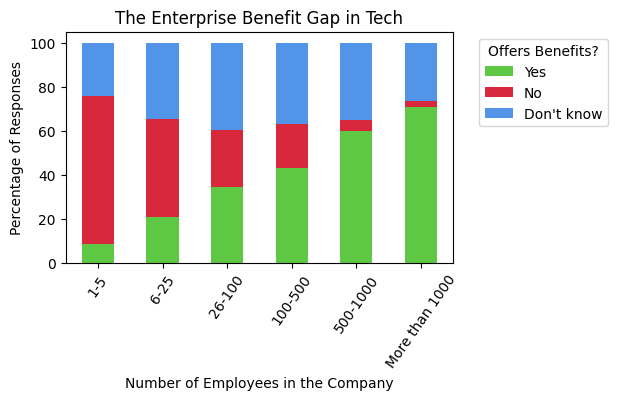

In [108]:
# Mapping Mental-Health Coverage Benefits with Company Size
df['no_employees'].value_counts() # frequency of unique values in column no_employees

size_vs_benefits = df.groupby('no_employees')['benefits'].value_counts(normalize=True).unstack() # getting a Yes/No/Don't_Know split for every company size 
reorderlist = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
size_vs_benefits = size_vs_benefits.reindex(reorderlist) # arranging the x-axis in ascending order
size_vs_benefits = size_vs_benefits[['Yes', 'No', "Don't know"]] #arranging the stacks in the y-axis from Yes > No > Don'tKnow
size_vs_benefits = size_vs_benefits*100 # converting decimals to percentages

# stacked bar graph
size_vs_benefits.plot(kind='bar', stacked=True, figsize=(5,3), color=["#42BE23D9", "#D0021AD9", "#3682E5DB"])
plt.title('The Enterprise Benefit Gap in Tech')
plt.xlabel('Number of Employees in the Company')
plt.ylabel("Percentage of Responses")
plt.legend(title='Offers Benefits?', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=55)

# Conclusion: Companies with higher employee strength offer significantly more mental-health benefits

In [109]:
# Within companies, for people struggling with mental health,
# does anonymity significantly help in seeking treatment?

# making a dataframe with people whose mental health interferes with their work 'Sometimes', 'Often' or 'Unknown'
df_interfere = df[(df['work_interfere'] != 'Never') & (df['work_interfere'] != 'Rarely')]
anonymity_vs_treatment = df_interfere.groupby('anonymity')['treatment'].value_counts(normalize=True).unstack()
anonymity_vs_treatment = (anonymity_vs_treatment*100).round(2)
anonymity_vs_treatment

# Conclusion: There is a 12 percentage point increase in seeking treatment just based on the perception of privacy 

treatment,No,Yes
anonymity,,
Don't know,51.55,48.45
No,45.83,54.17
Yes,34.13,65.87


(array([0, 1]), [Text(0, 0, 'Physical Health'), Text(1, 0, 'Mental Health')])

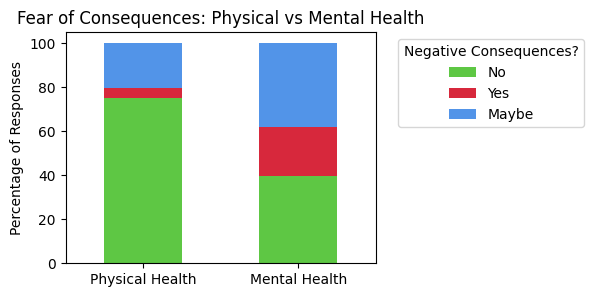

In [110]:
# Now, we can look at why anonymity helps- 
# Is it because of the perception of mental health in the workplace?
# Mapped in comparison to physical health for better context

mental_health_consq = df['mental_health_consequence'].value_counts(normalize=True)
physical_health_consq = df['phys_health_consequence'].value_counts(normalize=True)

stigma_comparison = pd.concat([physical_health_consq, mental_health_consq], axis=1)
stigma_comparison.columns = ['Physical Health', 'Mental Health']
stigma_comparison = (stigma_comparison*100).round(2).T
stigma_comparison = stigma_comparison[['No', 'Yes', 'Maybe']]

stigma_comparison.plot(kind='bar', figsize=(4,3), stacked=True, color=["#42BE23D9", "#D0021AD9", "#3682E5DB"])
plt.title('Fear of Consequences: Physical vs Mental Health')
plt.ylabel("Percentage of Responses")
plt.legend(title='Negative Consequences?', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# Conclusion: There is a 6x Higher Fear of Consequence for mental health reporting

(array([0, 1]), [Text(0, 0, 'Coworker'), Text(1, 0, 'Supervisor')])

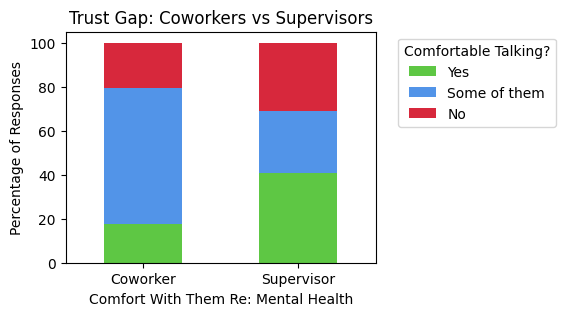

In [111]:
# From the chart above, it is clear that there is a 6x higher fear of consequence for mental health reporting  
# So are employees fearful of peers or bosses?

coworker_trust = df['coworkers'].value_counts(normalize=True)
supervisor_trust = df['supervisor'].value_counts(normalize=True)

trust_comparison = pd.concat([coworker_trust, supervisor_trust], axis=1)
trust_comparison.columns = ['Coworker', 'Supervisor']
trust_comparison = (trust_comparison*100).round(2).T
trust_comparison = trust_comparison[['Yes', 'Some of them', 'No']]

trust_comparison.plot(kind='bar', figsize=(4,3), stacked=True, color=["#42BE23D9", "#3682E5DB", "#D0021AD9"])
plt.title('Trust Gap: Coworkers vs Supervisors')
plt.xlabel("Comfort With Them Re: Mental Health")
plt.ylabel("Percentage of Responses")
plt.legend(title='Comfortable Talking?', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# Conclusion: Employees are actually 2x MORE comfortable speaking to their supervisors regarding mental health than all their coworkers
# Caveat: The %age of people who specifically reported NOT being comfortable talking to supervisors is still 1.5x higher than coworkers

(array([0, 1]), [Text(0, 0, 'Mental-Health'), Text(1, 0, 'Physical-Health')])

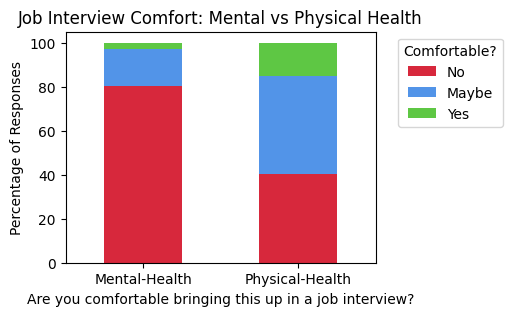

In [112]:
# Are employees comfortable bringing up mental health in a future job interview? 
# Mapped in comparison to physical health for better context

mental_interview = df['mental_health_interview'].value_counts(normalize=True)
phys_interview = df['phys_health_interview'].value_counts(normalize=True)

interview_comparison = pd.concat([mental_interview, phys_interview], axis=1)
interview_comparison.columns = ['Mental-Health', 'Physical-Health']
interview_comparison = (interview_comparison*100).round(2).T
interview_comparison = interview_comparison[['No', 'Maybe', 'Yes']]

interview_comparison.plot(kind='bar', figsize=(4,3), stacked=True, color=["#D0021AD9", "#3682E5DB", "#42BE23D9"])
plt.title('Job Interview Comfort: Mental vs Physical Health')
plt.xlabel("Are you comfortable bringing this up in a job interview?")
plt.ylabel("Percentage of Responses")
plt.legend(title='Comfortable?', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)


In [113]:
# Cost of Not Investing in Mental Health: 'Treatment vs Work Interfered' Mapping

cost_data = df[(df['work_interfere']!='Unknown')]
cost_data.groupby('treatment')['work_interfere'].value_counts(normalize=True).unstack().round(2)

# Conclusion: 78% of people in treatment still experience mental health interefering with their work 
                                                             # either 'Sometimes' or 'Often', 
                                                             # making it a chronic productivity risk!

work_interfere,Never,Often,Rarely,Sometimes
treatment,,,,
No,0.50,0.06,0.14,0.30
Yes,0.05,0.16,0.20,0.58
